# Nonlinear MPC in closed loop with `scaly.ocp`: a soft track limit, a mismatched plant, IPOPT and SQP

The cart-pole swing-up of `examples/notebooks/nmpc_cartpole.ipynb`, written with `scaly.ocp`
instead of by hand: a `ContinuousOCP` transcribed by multiple shooting, its solver
`sc.ocp.solver(problem, sc.ocp.Direct(...))` around IPOPT, and a closed loop written out in a few
lines against a plant that is not the controller's model, an adaptive integration of a cart-pole
whose pole is 20% heavier. The track limit is soft. The notebook shows where it gives way and why
it must, reads whole plans from the solver, composes the control law as one Function the way a C
caller would run it, and runs the same closed loop with scaly's own SQP.

| Scaly feature | Where |
| --- | --- |
| `sc.ocp.ContinuousOCP`, `sc.ocp.transcribe(..., sc.ocp.MultipleShooting(si.RK4(steps=2)), N=...)` | the controller |
| `sc.ocp.Path(position, lo, hi, soft=...)` | the controller; where the soft limit gives way |
| `si.adaptive(model, "dopri5", dt=..., rtol=..., atol=...)` | the plant |
| `sc.ocp.initial_guess`, `method.layout(problem)` | the first solve |
| `sc.ocp.solver(problem, sc.ocp.Direct(sc.opt.IPOPT(...)))`, `sc.ocp.shift` | the closed loop |
| a law `@sc.function` of the solver and the shift, `method.warm_size(problem)` | the control law as one Function; the generated C |
| `xs, us, point, info = solve(x0, warm)` | where the soft limit gives way; scaly's SQP |
| `sc.ocp.Direct(sc.opt.SQP(...))` | scaly's SQP |

This notebook needs the vendored IPOPT and the scaly SQP plugin.

In [1]:
import sys
from collections import Counter
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly import ocp
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "ocp" / "nmpc_closed_loop"

## The controller

The model, weights and limits are those of `nmpc_cartpole`: cart position $p$, pole angle $\theta$
from upright, their rates, a force $|u| \le 15$ N and a track $|p| \le 1$ m. Every 50 ms the
controller solves

$$
\begin{aligned}
\min_{x, u, s}\ & \Delta t \sum_{k=0}^{N-1} l(x_k, u_k) + l_N(x_N) + \rho \sum_{k=0}^{N-1} s_k \\
\text{s.t.}\ & x_0 = \hat x, \quad x_{k+1} = F(x_k, u_k), \quad |u_k| \le 15, \quad -1 - s_k \le p_k \le 1 + s_k, \quad s_k \ge 0 \quad (k < N),
\end{aligned}
$$

with $F$ two RK4 substeps of $\Delta t = 50$ ms, $N = 40$, $l = 2p^2 + 20\,(1 - \cos\theta)^2 + 0.1\,(\dot p^2 + \dot\theta^2) + 0.02\,u^2$,
$l_N$ ten times its state part, and $\hat x$ the measured state. `ocp.Path(position, lo=-1, hi=1, soft=1e3)`
adds the slacks $s_k$ and their penalty $\rho = 10^3$. The penalty is exact: when the hard limit
can be met, with multipliers below $\rho$, the soft problem has the same solution, and when it
cannot, the soft problem still has one, violating the limit by as little as it can.

The continuous problem runs over $T = N \Delta t = 2$ s; `ocp.transcribe` cuts it into $N$
intervals and makes it a `DiscreteOCP`, whose solver is one Function,
`xs, us, point, info = solve(x0, warm)`: the plan, the primal-dual point the solve reached, and
IPOPT's report, from the warm start `warm`.

In [2]:
NX, NU, N, DT = 4, 1, 40, 0.05
M_CART, M_POLE, LENGTH, G = 1.0, 0.3, 0.5, 9.81
U_MAX, P_MAX, SOFT = 15.0, 1.0, 1e3
Q = np.array([2.0, 20.0, 0.1, 0.1])  # p, 1 - cos(theta), rates
R, QN = 0.02, 10.0
X0 = np.array([0.0, np.pi, 0.0, 0.0])


def dynamics(x, u, m_pole):
  theta, pd, td = x[1], x[2], x[3]
  s, c = theta.sin(), theta.cos()
  den = M_CART + m_pole * s * s
  pdd = (u[0] + m_pole * LENGTH * td * td * s - m_pole * G * s * c) / den
  tdd = (G * s * (M_CART + m_pole) - c * (u[0] + m_pole * LENGTH * td * td * s)) / (LENGTH * den)
  return sc.stack([pd, td, pdd, tdd])


@sc.function(NX, NU, output="xdot", name="closed_loop_cartpole")
def cartpole(x, u):
  return dynamics(x, u, M_POLE)


def error(x):
  return sc.stack([x[0], 1.0 - x[1].cos(), x[2], x[3]])


@sc.function(NX, NU, output="l", name="closed_loop_stage")
def stage(x, u):
  e = error(x)
  return (sc.const(Q) * e * e).sum() + R * u[0] * u[0]


@sc.function(NX, output="vf", name="closed_loop_terminal")
def terminal(x):
  e = error(x)
  return QN * (sc.const(Q) * e * e).sum()


@sc.function(NX, NU, output="p", name="closed_loop_position")
def position(x, u):
  return x[:1]


def swing_up(name, soft=SOFT):
  continuous = ocp.ContinuousOCP(
    cartpole,
    T=N * DT,
    stage_cost=stage,
    terminal_cost=terminal,
    u_bounds=(-U_MAX, U_MAX),
    constraints=[ocp.Path(position, lo=-P_MAX, hi=P_MAX, soft=soft)],
    name=name,
  )
  return ocp.transcribe(continuous, ocp.MultipleShooting(si.RK4(steps=2)), N=N)


problem = swing_up("closed_loop_ipopt_ocp")
method = ocp.Direct(sc.opt.IPOPT(options={"tol": 1e-8, "max_iter": 500}))
solve, shift = ocp.solver(problem, method), ocp.shift(problem, method)
layout, (nlp, _) = method.layout(problem), ocp.to_problem(problem)
print(f"variables {dict(zip(layout.var_names, layout.var_sizes, strict=True))}, {nlp.n_eq} equalities, {nlp.n_ineq} inequalities")
print(f"{solve.name}{solve.input_names} -> {solve.output_names}")

variables {'xs': 164, 'us': 40, 'slack': 40}, 164 equalities, 80 inequalities
closed_loop_ipopt_ocp_ipopt('x0', 'warm') -> ('xs', 'us', 'point', 'info:status', 'info:iter', 'info:objective', 'info:primal_residual')


The variables are the 41 states, the 40 forces and 40 slacks. The 80 inequality rows are the soft
limit's two sides, $p_k - s_k \le 1$ and $p_k + s_k \ge -1$.

## The plant

The plant integrates a cart-pole whose pole weighs 0.36 kg instead of 0.3 kg with `si.adaptive`:
Dormand-Prince 5(4) with error control in a `while_loop`, tolerances 1e-10 and 1e-12, one call per
sample. A second plant integrates the controller's own model the same way, to separate what the
mismatch does from what the controller does.

In [3]:
M_POLE_PLANT = 1.2 * M_POLE


@sc.function(NX, NU, output="xdot", name="closed_loop_heavier")
def heavier(x, u):
  return dynamics(x, u, M_POLE_PLANT)


plant = si.adaptive(heavier, "dopri5", dt=DT, rtol=1e-10, atol=1e-12, name="closed_loop_plant")
nominal_plant = si.adaptive(cartpole, "dopri5", dt=DT, rtol=1e-10, atol=1e-12, name="closed_loop_nominal_plant")

## The first solve

`ocp.initial_guess(problem, method, x0)` puts every state at $x_0$ and every force at 0. Hanging
still with no force is a KKT point of the first problem, by symmetry: the cost's gradient in the
angle, $\sin\theta$, is zero at $\theta = \pi$, and nothing favours swinging one way. IPOPT started
there stays there. A warm start whose forces pump the pole, one period over the horizon, breaks the
tie; `start` builds it from `initial_guess` by replacing the force block, which the method's
`layout` locates in the flat point.

In [4]:
def start(problem, x, **leaves):
  """ocp.initial_guess at x with the named variable leaves (xs, us, slack) replaced."""
  guess, layout, cut = ocp.initial_guess(problem, method, x), method.layout(problem), 0
  for name, size in zip(layout.var_names, layout.var_sizes, strict=True):
    if name in leaves:
      guess[cut : cut + size] = np.ravel(leaves[name])
    cut += size
  return guess


def slack(point):
  """The slack leaf of a flat point of `problem`."""
  i = layout.var_names.index("slack")
  cut = sum(layout.var_sizes[:i])
  return np.asarray(point)[cut : cut + layout.var_sizes[i]]


def status(info):
  return sc.Status(int(info.status)).name


pumping = start(problem, X0, us=0.5 * U_MAX * np.sin(2 * np.pi * np.arange(N) / N))
_, hanging_us, _, hanging = solve(X0, ocp.initial_guess(problem, method, X0))
hanging_force = float(np.abs(hanging_us).max())
print(
  f"from initial_guess: {status(hanging)} after {int(hanging.iter)} iterations, cost {float(hanging.objective):.1f}, largest force {hanging_force:.1e} N"
)

from initial_guess: OK after 7 iterations, cost 960.0, largest force 5.9e-14 N


IPOPT converges, in 7 iterations, to the pole hanging still, with a cost of 960 and no force.

## The closed loop

The receding horizon is a loop the notebook writes itself: at each sample, solve from the measured
state, apply the first force for 50 ms, and move the point the solve reached up one interval with
`shift`, the warm start of the next solve. The shift is a Function too: every stage's block of
states, forces, slacks and their multipliers takes the next stage's value, the last one repeated.
The loop records IPOPT's status, iterations and its own time for each solve. It runs from the pumping
start against the heavier pole, and the same loop against the controller's own model follows.

In [5]:
def closed_loop(solve, shift, plant, x0, warm, steps):
  """`steps` samples of the receding horizon on `plant`, from the warm start `warm`."""
  x, xs, us, statuses, iterations, times = x0, [x0], [], [], [], []
  for _ in range(steps):
    _, plan, point, info = solve(x, warm)
    times.append(sc.opt.solver_stats(solve).t_total)  # the nested solver's own time
    warm = shift(point)
    statuses.append(status(info))
    iterations.append(int(info.iter))
    x = np.asarray(plant(x, plan[0]))
    xs.append(x)
    us.append(plan[0])
  return SimpleNamespace(xs=np.array(xs), us=np.array(us), statuses=statuses, iterations=np.array(iterations), solve_times=np.array(times))


STEPS = 100
run = closed_loop(solve, shift, plant, X0, pumping, STEPS)
nominal = closed_loop(solve, shift, nominal_plant, X0, pumping, STEPS)

t = DT * np.arange(STEPS + 1)
statuses, nominal_statuses = dict(Counter(run.statuses)), dict(Counter(nominal.statuses))
upright = np.abs(np.cos(run.xs[:, 1]) - 1) < 1e-2
upright_from = float(DT * (len(upright) - np.argmin(upright[::-1]))) if upright.any() else np.inf
u_max, p_max, p_max_nominal = float(np.abs(run.us).max()), float(np.abs(run.xs[:, 0]).max()), float(np.abs(nominal.xs[:, 0]).max())
worst = int(np.argmax(np.abs(run.xs[:STEPS, 0])))
it = run.iterations
print(f"heavier pole: statuses {statuses}; model as plant: {nominal_statuses}")
print(
  f"IPOPT iterations: first {it[0]}, then {it[1:].min()} to {it[1:].max()}, median {np.median(it[1:]):.0f}; median solve {1e3 * np.median(run.solve_times):.2f} ms"
)
print(f"upright within 1e-2 for good from t = {upright_from:.2f} s; final state {np.array2string(run.xs[-1], precision=4)}")
print(f"largest |u| {u_max:.3f} N; largest |p| {p_max:.5f} m at step {worst} (model as plant: {p_max_nominal:.7f} m)")

heavier pole: statuses {'OK': 100}; model as plant: {'OK': 100}
IPOPT iterations: first 43, then 6 to 22, median 6; median solve 2.28 ms
upright within 1e-2 for good from t = 2.05 s; final state [ 0.0004 -0.0005  0.0001  0.0013]
largest |u| 15.000 N; largest |p| 1.01067 m at step 17 (model as plant: 1.0000006 m)


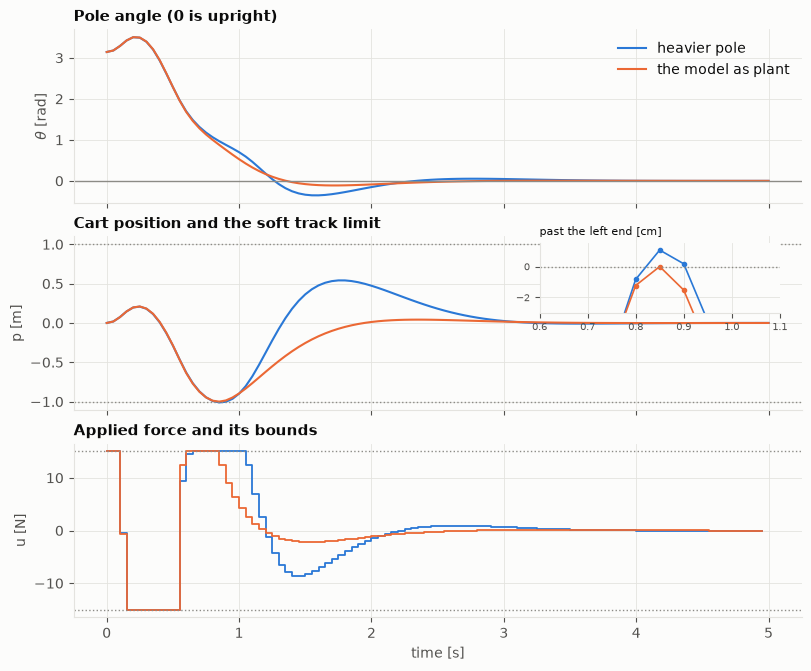

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True)
for series, label, color in ((run, "heavier pole", plotstyle.BLUE), (nominal, "the model as plant", plotstyle.ORANGE)):
  axes[0].plot(t, series.xs[:, 1], color=color, lw=1.5, label=label)
  axes[1].plot(t, series.xs[:, 0], color=color, lw=1.5)
  axes[2].step(t[:-1], series.us[:, 0], where="post", color=color, lw=1.3)
axes[0].axhline(0, color=plotstyle.NEUTRAL, lw=1)
axes[0].set_ylabel(r"$\theta$ [rad]")
axes[0].set_title("Pole angle (0 is upright)")
axes[0].legend(loc="upper right")
for bound in (-P_MAX, P_MAX):
  axes[1].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[1].set_ylabel("p [m]")
axes[1].set_title("Cart position and the soft track limit")
zoom = axes[1].inset_axes((0.64, 0.56, 0.33, 0.4))
for series, color in ((run, plotstyle.BLUE), (nominal, plotstyle.ORANGE)):
  zoom.plot(t, 100 * (-series.xs[:, 0] - P_MAX), "o-", ms=3, lw=1.2, color=color)
zoom.axhline(0, color=plotstyle.NEUTRAL, lw=1, ls=":")
zoom.set_xlim(0.6, 1.1)
zoom.set_ylim(-3, 1.5)
zoom.set_title("past the left end [cm]", fontsize=8, fontweight="normal")
zoom.tick_params(labelsize=7)
for bound in (-U_MAX, U_MAX):
  axes[2].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[2].set_ylabel("u [N]")
axes[2].set_title("Applied force and its bounds")
axes[2].set_xlabel("time [s]")
plt.show()

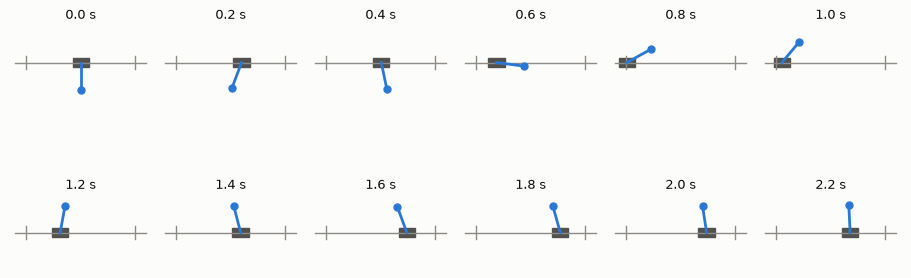

In [7]:
frames = np.arange(0, 48, 4)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, k in zip(axes.flat, frames, strict=True):
  p, theta = run.xs[k, 0], run.xs[k, 1]
  tip = (p + LENGTH * np.sin(theta), LENGTH * np.cos(theta))
  ax.plot([-P_MAX - 0.2, P_MAX + 0.2], [0, 0], color=plotstyle.NEUTRAL, lw=1)
  for end in (-P_MAX, P_MAX):
    ax.plot([end, end], [-0.12, 0.12], color=plotstyle.NEUTRAL, lw=1)
  ax.add_patch(plt.Rectangle((p - 0.15, -0.08), 0.3, 0.16, color=plotstyle.TEXT_SECONDARY))
  ax.plot([p, tip[0]], [0, tip[1]], color=plotstyle.BLUE, lw=2)
  ax.plot(*tip, "o", color=plotstyle.BLUE, ms=5)
  ax.set_xlim(-1.3, 1.3)
  ax.set_ylim(-0.65, 0.65)
  ax.set_aspect("equal")
  ax.axis("off")
  ax.set_title(f"{t[k]:.1f} s", fontsize=9, fontweight="normal", loc="center")
plt.show()

Against the heavier pole the controller still swings the pole up with one pump. The pole is
upright to within 1e-2 for good from 2.05 s, and after 5 s the state is within 1.3e-3 of the
origin. The heavier pole needs a larger correction after the swing: the force goes down to about
-8.5 N at 1.4 s where the model as plant needs -2 N, and the cart swings out to 0.55 m. Both
loops hold the force at its bounds during the swing. IPOPT takes 43 iterations for the first
solve, 11 to 22 through the swing-up, where the plan changes most between samples, and 6 once the
pole is up, 2.3 ms per solve at the median. The filmstrip shows the heavier-pole run every 0.2 s.

## The control law as one Function

The solver and the shift are Functions, so the controller is one too: a `@sc.function` that
solves, keeps the first force and shifts the point, `law(x0, warm) -> (u, warm_next)`. It nests
both calls in one graph, and in C it is one function whose caller keeps one buffer of
`method.warm_size(problem)` doubles and passes it back at every sample. Run by hand from the
same pumping start, it must reproduce the closed loop exactly. The loop keeps each sample's warm
start for the next section.

In [8]:
WARM = method.warm_size(problem)


@sc.function(sc.L("x0", NX), sc.L("warm", WARM), output=sc.G("u", "warm_next"), name="closed_loop_law")
def law(x0, warm):
  _, us, point, _ = solve(x0, warm)
  return us[0], shift(point)


warm, x, xs, warms = pumping, X0, [X0], []
for _ in range(STEPS):
  warms.append(warm)
  u, warm = law(x, warm)
  x = np.asarray(plant(x, u))
  xs.append(x)
law_gap = float(np.abs(np.array(xs) - run.xs).max())
print(f"law{law.input_names} -> {law.output_names}, warm_size {WARM}")
print(f"by hand, the closed loop to {law_gap:.1e}")

law('x0', 'warm') -> ('u', 'warm_next'), warm_size 732
by hand, the closed loop to 0.0e+00


The warm start is the whole primal-dual point: 244 variables, their 244 bound multipliers, 164
equality and 80 inequality multipliers, 732 doubles.

## Where the soft limit gives way

Against the controller's own model the cart stays on the track, to 6e-7, the model's integration
error. Against the heavier pole it runs 1.07 cm past the left end at 0.85 s. `solve(x, warm)`
returns the whole plan at a state, and from the warm start the law had at that sample it is the
plan the closed loop followed. The plans from the start to the worst sample show from which sample
on they need slack. The same OCP with the limit hard (`soft=None`) then shows whether they had a
choice.

In [9]:
hard_problem = swing_up("closed_loop_hard_ocp", soft=None)
hard = ocp.solver(hard_problem, method)
plans = [solve(run.xs[k], warms[k]) for k in range(worst + 1)]
plan_slacks = np.array([float(slack(point).max()) for _, _, point, _ in plans])
hard_statuses = [status(hard(run.xs[k], start(hard_problem, run.xs[k], xs=plans[k][0], us=plans[k][1]))[3]) for k in range(worst + 1)]
needs = int(np.argmax(plan_slacks > 1e-6))  # the first plan that gives way
at_xs, at_us, at_point, _ = plans[worst]
at_slack = slack(at_point)
slack_now, slack_next, slack_rest = float(at_slack[0]), float(at_slack[1]), float(np.abs(at_slack[2:]).max())
worst_u_gap = float(np.abs(at_us[0] - run.us[worst]).max())
print(f"{'step':>4} {'largest planned slack':>22} {'hard limit':>18}")
for k in range(needs - 2, worst + 1):
  print(f"{k:4d} {plan_slacks[k]:22.1e} {hard_statuses[k]:>18}")
print(f"hard limit OK up to step {needs - 1}, {Counter(hard_statuses[needs:])} from step {needs}")
print(f"step {worst}: slack {slack_now:.5f} now, {slack_next:.1e} at the next stage, within {slack_rest:.0e} of zero after")
print(f"its first force is the closed loop's to {worst_u_gap:.0e}; xs {at_xs.shape}, us {at_us.shape}, point {at_point.shape}, slack {at_slack.shape}")

step  largest planned slack         hard limit
  11               -1.0e-08                 OK
  12               -1.0e-08                 OK
  13                1.9e-03  PRIMAL_INFEASIBLE
  14                5.1e-03  PRIMAL_INFEASIBLE
  15                8.1e-03  PRIMAL_INFEASIBLE
  16                1.0e-02  PRIMAL_INFEASIBLE
  17                1.1e-02  PRIMAL_INFEASIBLE
hard limit OK up to step 12, Counter({'PRIMAL_INFEASIBLE': 5}) from step 13
step 17: slack 0.01067 now, 1.1e-03 at the next stage, within 1e-08 of zero after
its first force is the closed loop's to 0e+00; xs (41, 4), us (40, 1), point (732,), slack (40,)


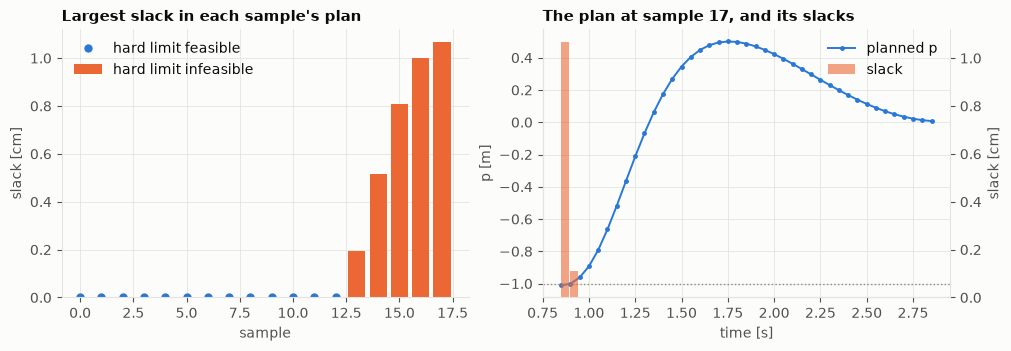

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
feasible = np.array([s == "OK" for s in hard_statuses])
steps = np.arange(worst + 1)
ax1.plot(steps[feasible], 100 * np.maximum(plan_slacks[feasible], 0), "o", color=plotstyle.BLUE, label="hard limit feasible")
ax1.bar(steps[~feasible], 100 * plan_slacks[~feasible], color=plotstyle.ORANGE, label="hard limit infeasible")
ax1.set_xlabel("sample")
ax1.set_ylabel("slack [cm]")
ax1.set_title("Largest slack in each sample's plan")
ax1.legend(loc="upper left")
horizon = DT * (worst + np.arange(N + 1))
ax2.plot(horizon, at_xs[:, 0], "o-", ms=2.5, color=plotstyle.BLUE, lw=1.4, label="planned p")
ax2.axhline(-P_MAX, color=plotstyle.NEUTRAL, lw=1, ls=":")
ax2.set_ylabel("p [m]")
ax2.set_xlabel("time [s]")
ax2.set_title(f"The plan at sample {worst}, and its slacks")
slack_axis = ax2.twinx()
slack_axis.bar(horizon[:-1], 100 * np.maximum(at_slack, 0), width=0.8 * DT, align="edge", color=plotstyle.ORANGE, alpha=0.6, label="slack")
slack_axis.set_ylabel("slack [cm]")
slack_axis.grid(False)
slack_axis.spines["right"].set_visible(True)
ax2.legend(handles=[*ax2.get_legend_handles_labels()[0], *slack_axis.get_legend_handles_labels()[0]], loc="upper right")
plt.show()

Up to sample 12 every plan keeps the cart on the track, and the hard-limit OCP has a solution at
each of those states. From sample 13 on, the heavier pole has carried the cart where the model can
no longer stop it before the end: every plan needs slack, 0.19 cm at sample 13 growing to 1.07 cm
at sample 17, and at every one of those states the hard-limit OCP has no solution, which IPOPT
reports as `PRIMAL_INFEASIBLE`. The soft limit gives way only where the hard one has no solution.
At sample 17 the cart is 1.067 cm past the end. The plan's first slack is exactly that violation,
the next 0.11 cm, which the cart's momentum makes unavoidable, and every later one zero: the plan
brings the cart back and swings it out to 0.5 m before returning to the origin. The solve from the
law's warm start returns the closed loop's force exactly.

## Scaly's SQP

`ocp.Direct(sc.opt.SQP(...))` puts scaly's own SQP, a filter line search around PIQP generated as
C, where IPOPT was: the same OCP, the same layout of the warm start. The QP subproblems get 200
iterations and a tolerance of 1e-9; with the plugin's defaults (50 and 1e-6) the first swing-up
solve ends at the iteration limit.

In [11]:
sqp_method = ocp.Direct(sc.opt.SQP(options={"tol": 1e-8, "max_iter": 300, "qp_max_iter": 200, "qp_tol": 1e-9}))
sqp_problem = swing_up("closed_loop_sqp_ocp")
sqp, sqp_shift = ocp.solver(sqp_problem, sqp_method), ocp.shift(sqp_problem, sqp_method)
_, _, _, sqp_cold = sqp(X0, pumping)
first = plans[0][3]
print(f"SQP from the pumping guess: {status(sqp_cold)}, cost {float(sqp_cold.objective):.2f} after {int(sqp_cold.iter)} iterations")
print(f"IPOPT from the same guess:  {status(first)}, cost {float(first.objective):.2f} after {it[0]} iterations")
sqp_run = closed_loop(sqp, sqp_shift, plant, X0, plans[0][2], STEPS)  # from IPOPT's first solution, primal and dual
sqp_statuses, sqp_iterations = dict(Counter(sqp_run.statuses)), sqp_run.iterations
sqp_state_gap, sqp_force_gap = float(np.abs(sqp_run.xs - run.xs).max()), float(np.abs(sqp_run.us - run.us).max())
print(f"SQP seeded with IPOPT's first solution: statuses {sqp_statuses}")
print(
  f"iterations {sqp_iterations.min()} to {sqp_iterations.max()}, median {np.median(sqp_iterations):.0f}; median solve {1e3 * np.median(sqp_run.solve_times):.2f} ms"
)
print(f"states within {sqp_state_gap:.1e} and forces within {sqp_force_gap:.1e} of IPOPT's closed loop")

SQP from the pumping guess: OK, cost 80.90 after 197 iterations
IPOPT from the same guess:  OK, cost 53.65 after 43 iterations


SQP seeded with IPOPT's first solution: statuses {'OK': 100}
iterations 1 to 7, median 2; median solve 1.44 ms
states within 4.8e-06 and forces within 4.6e-05 of IPOPT's closed loop


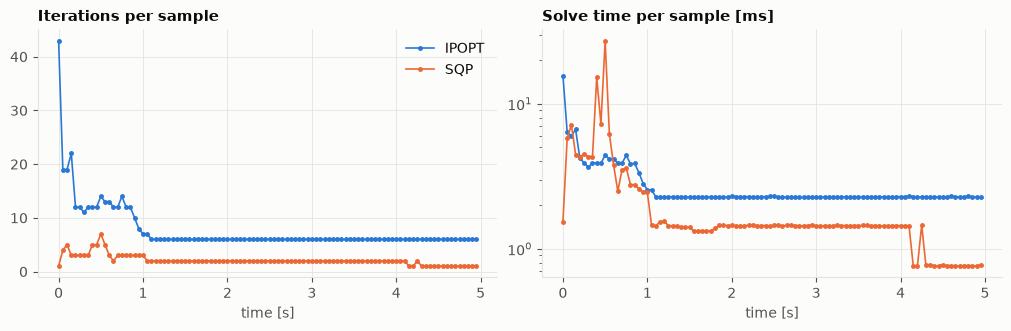

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.plot(t[:-1], run.iterations, "o-", ms=2.5, lw=1.2, color=plotstyle.BLUE, label="IPOPT")
ax1.plot(t[:-1], sqp_iterations, "o-", ms=2.5, lw=1.2, color=plotstyle.ORANGE, label="SQP")
ax1.set_xlabel("time [s]")
ax1.set_title("Iterations per sample")
ax1.legend(loc="upper right")
ax2.semilogy(t[:-1], 1e3 * run.solve_times, "o-", ms=2.5, lw=1.2, color=plotstyle.BLUE)
ax2.semilogy(t[:-1], 1e3 * sqp_run.solve_times, "o-", ms=2.5, lw=1.2, color=plotstyle.ORANGE)
ax2.set_xlabel("time [s]")
ax2.set_title("Solve time per sample [ms]")
plt.show()

From the pumping guess SQP converges to a worse local minimum, a cost of 80.90 against IPOPT's
53.65, after 197 iterations to IPOPT's 43. Seeded with IPOPT's first solution (the point of
`plans[0]`) it runs the same closed loop: every solve OK, the states within 4.8e-6 and the forces
within 4.6e-5 of IPOPT's, the two solvers' tolerances. From a shifted solution SQP needs 1 to 7
iterations, 2 at the median and 1 at the end, where IPOPT never needs fewer than 6: an
interior-point method starts every solve from its barrier parameter and follows it down again.
SQP's time follows the QP subproblems inside it: 1.4 ms a sample at the median, and an order of
magnitude more at the few swing-up samples where PIQP needs hundreds of iterations.

## Checks

In [13]:
iterations = run.iterations
assert statuses == nominal_statuses == sqp_statuses == {"OK": 100}
assert hanging_force < 1e-6
assert iterations[0] > 2 * np.median(iterations[1:])  # the warm start
assert upright_from < 3.0 and np.abs(run.xs[-1]).max() < 1e-2
assert u_max <= 15 + 1e-6
assert p_max_nominal < 1 + 1e-5 and 1.001 < p_max < 1.05  # the soft track limit gives way on the heavier pole
assert hard_statuses[needs - 1 : needs + 1] == ["OK", "PRIMAL_INFEASIBLE"]  # exactly where a hard limit has no solution
assert set(hard_statuses[:needs]) == {"OK"} and set(hard_statuses[needs:]) == {"PRIMAL_INFEASIBLE"}
assert plan_slacks[needs - 1] < 1e-6 and plan_slacks[needs] > 1e-4
assert abs(slack_now - (p_max - 1)) < 1e-6 and slack_rest < 1e-6
assert worst_u_gap < 1e-8 and law_gap < 1e-12
assert WARM == 732 and law.input_names == ("x0", "warm") and law.output_names == ("u", "warm_next")
assert sqp_state_gap < 5e-5 and sqp_force_gap < 5e-4
assert np.median(sqp_iterations) < np.median(iterations[1:]) and sqp_iterations.max() <= 20
print("14 checks passed")

14 checks passed


## The generated C

`write_module(law, ...)` writes the controller as one C module: the law, the shift, IPOPT's
generated wrapper and the oracles of the OCP. It links against the vendored IPOPT.

In [14]:
module = write_module(law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; the typed buffers in {module.header_name}:")
print(
  "\n".join(line for line in module.header.splitlines() if line.startswith("typedef struct") and "double data[" in line and "workspace" not in line)
)

closed_loop_law.c: 2907 lines, 225 kB; the typed buffers in closed_loop_law.h:
typedef struct { SCALY_ALIGNAS(16) double data[4]; } closed_loop_law_x0_t;
typedef struct { SCALY_ALIGNAS(16) double data[732]; } closed_loop_law_warm_t;
typedef struct { SCALY_ALIGNAS(16) double data[1]; } closed_loop_law_u_t;
typedef struct { SCALY_ALIGNAS(16) double data[732]; } closed_loop_law_warm_next_t;
